In [5]:
!pip install scikit-learn pandas numpy matplotlib joblib

In [6]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. On recharge les données depuis le disque dur
X_train, X_test, y_train, y_test = joblib.load("../models/train_test_data.pkl")
X_train_scaled, X_test_scaled = joblib.load("../models/scaled_data.pkl")

print("Données chargées en mémoire avec succès ! Les variables X_train, y_train, etc. sont prêtes.")

Données chargées en mémoire avec succès ! Les variables X_train, y_train, etc. sont prêtes.


--- Random Forest Report ---
              precision    recall  f1-score   support

      ATTACK       0.96      0.99      0.97    106090
      BENIGN       0.99      0.98      0.99    249697

    accuracy                           0.98    355787
   macro avg       0.98      0.98      0.98    355787
weighted avg       0.98      0.98      0.98    355787



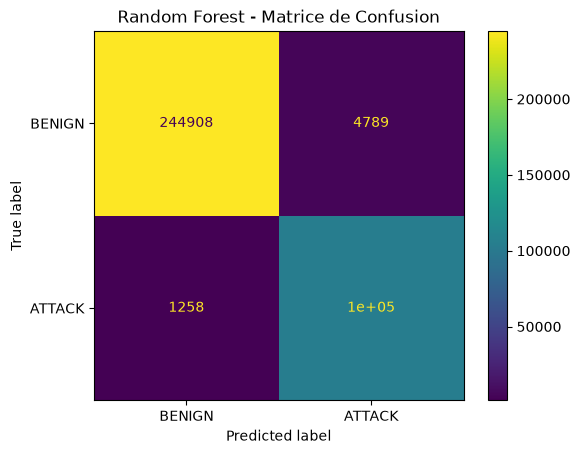

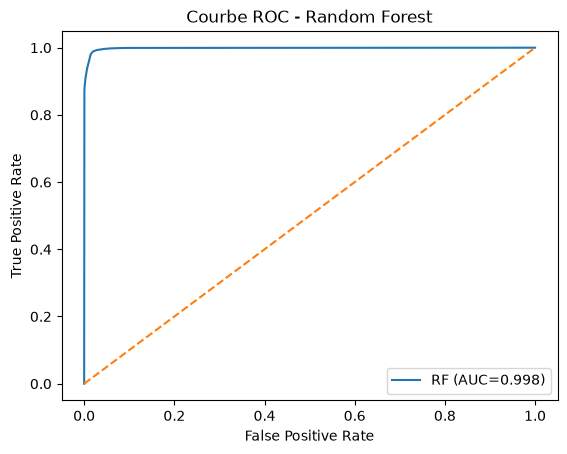

['../models/random_forest_v1.pkl']

In [8]:
# --- 2.1 RANDOM FOREST ---
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 0]

print("--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion RF
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["BENIGN", "ATTACK"])
ConfusionMatrixDisplay(cm_rf, display_labels=["BENIGN", "ATTACK"]).plot()
plt.title("Random Forest - Matrice de Confusion")
plt.show()

# Courbe ROC RF
fpr_rf, tpr_rf, _ = roc_curve(y_test.map({"BENIGN": 0, "ATTACK": 1}), y_proba_rf)
auc_rf = roc_auc_score(y_test.map({"BENIGN": 0, "ATTACK": 1}), y_proba_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.show()

joblib.dump(rf, "../models/random_forest_v1.pkl")